In [1]:
# Import all libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Load the weather classification dataset
# Update the file path to match your local directory structure
file_path = r"Data\weather_classification_data.csv"


df_weather = pd.read_csv(file_path)
print("Weather dataset loaded successfully!")
print(f"Dataset shape: {df_weather.shape}")
print(f"Columns: {df_weather.columns.tolist()}")


Weather dataset loaded successfully!
Dataset shape: (13200, 11)
Columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']


In [11]:
# Display the first 5 rows to understand the structure

print(df_weather.head())

print("\n DATASET INFO: ")
print(df_weather.info())

print("\n BASIC STATISTICS: ")
print(df_weather.describe())

print("\n DATA TYPES: ")
print(df_weather.dtypes)

   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  Weather_Type_encoded  
0        Rainy                     1  
1       Cloudy                     0  
2    

In [4]:

print(" MISSING VALUES: ")

# Count missing values per column
missing_counts = df_weather.isnull().sum()
missing_percentages = (df_weather.isnull().sum() / len(df_weather)) * 100

print(missing_counts)
print(missing_percentages)

print(f"\n Total missing values in dataset: {df_weather.isnull().sum().sum()}")

 MISSING VALUES: 
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64
Temperature             0.0
Humidity                0.0
Wind Speed              0.0
Precipitation (%)       0.0
Cloud Cover             0.0
Atmospheric Pressure    0.0
UV Index                0.0
Season                  0.0
Visibility (km)         0.0
Location                0.0
Weather Type            0.0
dtype: float64

 Total missing values in dataset: 0


In [5]:
# Identify column types for encoding
print("COLUMN TYPE IDENTIFICATION: ")

# separate numerical and categorical columns
numerical_columns = df_weather.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_weather.select_dtypes(include=['object']).columns.tolist()

print(f" Numerical columns ({len(numerical_columns)}):")
for col in numerical_columns:
    print(f"   - {col}")

print(f"\n Categorical columns ({len(categorical_columns)}):")
for col in categorical_columns:
    unique_count = df_weather[col].nunique() #check how many unique values categorical coloumns have
    print(f"   - {col} (unique values: {unique_count})")

# check target variable
target_column = 'Weather Type'  
print(f"\n Target variable: {target_column}")
print(f"   Classes: {df_weather[target_column].unique()}")
print(f"   Class distribution:") #check weather the target variable is balanced across the classes
print(df_weather[target_column].value_counts())   


COLUMN TYPE IDENTIFICATION: 
 Numerical columns (7):
   - Temperature
   - Humidity
   - Wind Speed
   - Precipitation (%)
   - Atmospheric Pressure
   - UV Index
   - Visibility (km)

 Categorical columns (4):
   - Cloud Cover (unique values: 4)
   - Season (unique values: 4)
   - Location (unique values: 3)
   - Weather Type (unique values: 4)

 Target variable: Weather Type
   Classes: ['Rainy' 'Cloudy' 'Sunny' 'Snowy']
   Class distribution:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


In [6]:
# Encode target variable (Weather Type)
target_encoder = LabelEncoder()
df_weather['Weather_Type_encoded'] = target_encoder.fit_transform(df_weather['Weather Type'])

print("Target encoding mapping:")
for i, class_name in enumerate(target_encoder.classes_):
    print(f"{class_name} -> {i}")

print(f"\nTarget distribution:")
print(df_weather['Weather_Type_encoded'].value_counts())
df_weather.head()

Target encoding mapping:
Cloudy -> 0
Rainy -> 1
Snowy -> 2
Sunny -> 3

Target distribution:
Weather_Type_encoded
1    3300
0    3300
3    3300
2    3300
Name: count, dtype: int64


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Weather_Type_encoded
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,3
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,3
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,1


In [7]:
# Get all categorical columns but not target 
categorical_features = [col for col in categorical_columns if col != 'Weather Type']

# One-hot encode all other categorical features: Cloud Cover, Season, and Location 
df_encoded = pd.get_dummies(df_weather, columns=categorical_features, drop_first=True) #drop_first true when all other column are false then 1st one is true

print(f"Dataset shape after encoding: {df_encoded.shape}")
print(f"New columns: {df_encoded.shape[1] - df_weather.shape[1]} added")

df_encoded.head()


Dataset shape after encoding: (13200, 17)
New columns: 5 added


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Weather_Type_encoded,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,Rainy,1,False,False,True,False,False,True,True,False
1,39.0,96,8.5,71.0,1011.43,7,10.0,Cloudy,0,False,False,True,True,False,False,True,False
2,30.0,64,7.0,16.0,1018.72,5,5.5,Sunny,3,False,False,False,True,False,False,False,True
3,38.0,83,1.5,82.0,1026.25,7,1.0,Sunny,3,False,False,False,True,False,False,False,False
4,27.0,74,17.0,66.0,990.67,1,2.5,Rainy,1,False,True,False,False,False,True,False,True


In [8]:
# Get numerical columns for scaling
numerical_cols_to_scale = df_encoded.select_dtypes(include=[np.number]).columns
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col != 'Weather_Type_encoded']

# Standardize numerical features
scaler = StandardScaler()
df_encoded[numerical_cols_to_scale] = scaler.fit_transform(df_encoded[numerical_cols_to_scale])

print("Standardization completed!")
print(f"Columns standardized: {list(numerical_cols_to_scale)}")
print(df_encoded.shape)
df_encoded.head()

Standardization completed!
Columns standardized: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
(13200, 17)


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Weather_Type_encoded,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,Rainy,1,False,False,True,False,False,True,True,False
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,Cloudy,0,False,False,True,True,False,False,True,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,Sunny,3,False,False,False,True,False,False,False,True
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,Sunny,3,False,False,False,True,False,False,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,Rainy,1,False,True,False,False,False,True,False,True


In [9]:
# Prepare X and y
X = df_encoded.drop(['Weather Type', 'Weather_Type_encoded'], axis=1) #axis=1 means droping columns not row if droppig rows then axis=0
y = df_encoded['Weather_Type_encoded']

# Split data 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # 80% train and 20% test

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Features: {X.shape[1]}")

Training set: (10560, 15)
Testing set: (2640, 15)
Features: 15


In [10]:
display(df_weather.head())
display(df_encoded.head())

print("CLASSIFICATION DATA PREPARATION COMPLETE: ")

print(f"Original shape: {df_weather.shape}")
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Weather_Type_encoded
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,3
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,3
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,1


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Weather_Type_encoded,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,Rainy,1,False,False,True,False,False,True,True,False
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,Cloudy,0,False,False,True,True,False,False,True,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,Sunny,3,False,False,False,True,False,False,False,True
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,Sunny,3,False,False,False,True,False,False,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,Rainy,1,False,True,False,False,False,True,False,True


CLASSIFICATION DATA PREPARATION COMPLETE: 
Original shape: (13200, 12)
Final X shape: (13200, 15)
Final y shape: (13200,)
Train set: 10560 samples
Test set: 2640 samples


In [14]:
print("WEATHER CLASSIFICATION EDA: ")
print(f"Dataset shape: {df_encoded.shape}")
print(f"Features: {X_train.shape[1]}")

WEATHER CLASSIFICATION EDA: 
Dataset shape: (13200, 17)
Features: 15


In [17]:
print("SUMMARY STATISTICS (ENCODED FEATURES):")
numerical_features = df_encoded.select_dtypes(include=[np.number]).columns
print(f"Numerical features ({len(numerical_features)}): {list(numerical_features)}")
print(df_encoded[numerical_features].describe())

SUMMARY STATISTICS (ENCODED FEATURES):
Numerical features (8): ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Weather_Type_encoded']
        Temperature      Humidity    Wind Speed  Precipitation (%)  \
count  1.320000e+04  1.320000e+04  1.320000e+04       1.320000e+04   
mean  -6.136505e-17  3.445056e-16  2.368476e-17       1.098112e-16   
std    1.000038e+00  1.000038e+00  1.000038e+00       1.000038e+00   
min   -2.538158e+00 -2.412206e+00 -1.423215e+00      -1.679256e+00   
25%   -8.701176e-01 -5.799313e-01 -6.994626e-01      -1.084490e+00   
50%    1.076993e-01  6.384073e-02 -1.204609e-01       1.363456e-01   
75%    6.828857e-01  7.571337e-01  5.309161e-01       8.876291e-01   
max    5.169340e+00  1.995157e+00  5.597181e+00       1.732823e+00   

       Atmospheric Pressure      UV Index  Visibility (km)  \
count          1.320000e+04  1.320000e+04     1.320000e+04   
mean          -5.307539e-16  4.844610e-1

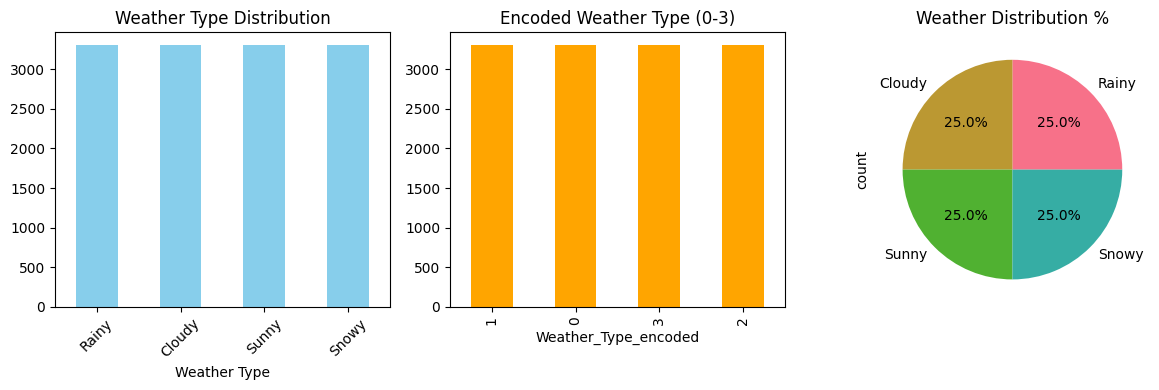

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df_encoded['Weather Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Weather Type Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df_encoded['Weather_Type_encoded'].value_counts().plot(kind='bar', color='orange')
plt.title('Encoded Weather Type (0-3)')

plt.subplot(1, 3, 3)
df_encoded['Weather Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Weather Distribution %')

plt.tight_layout()
plt.show()

#so aftering running this cell we know that our target variable is equally distributed 

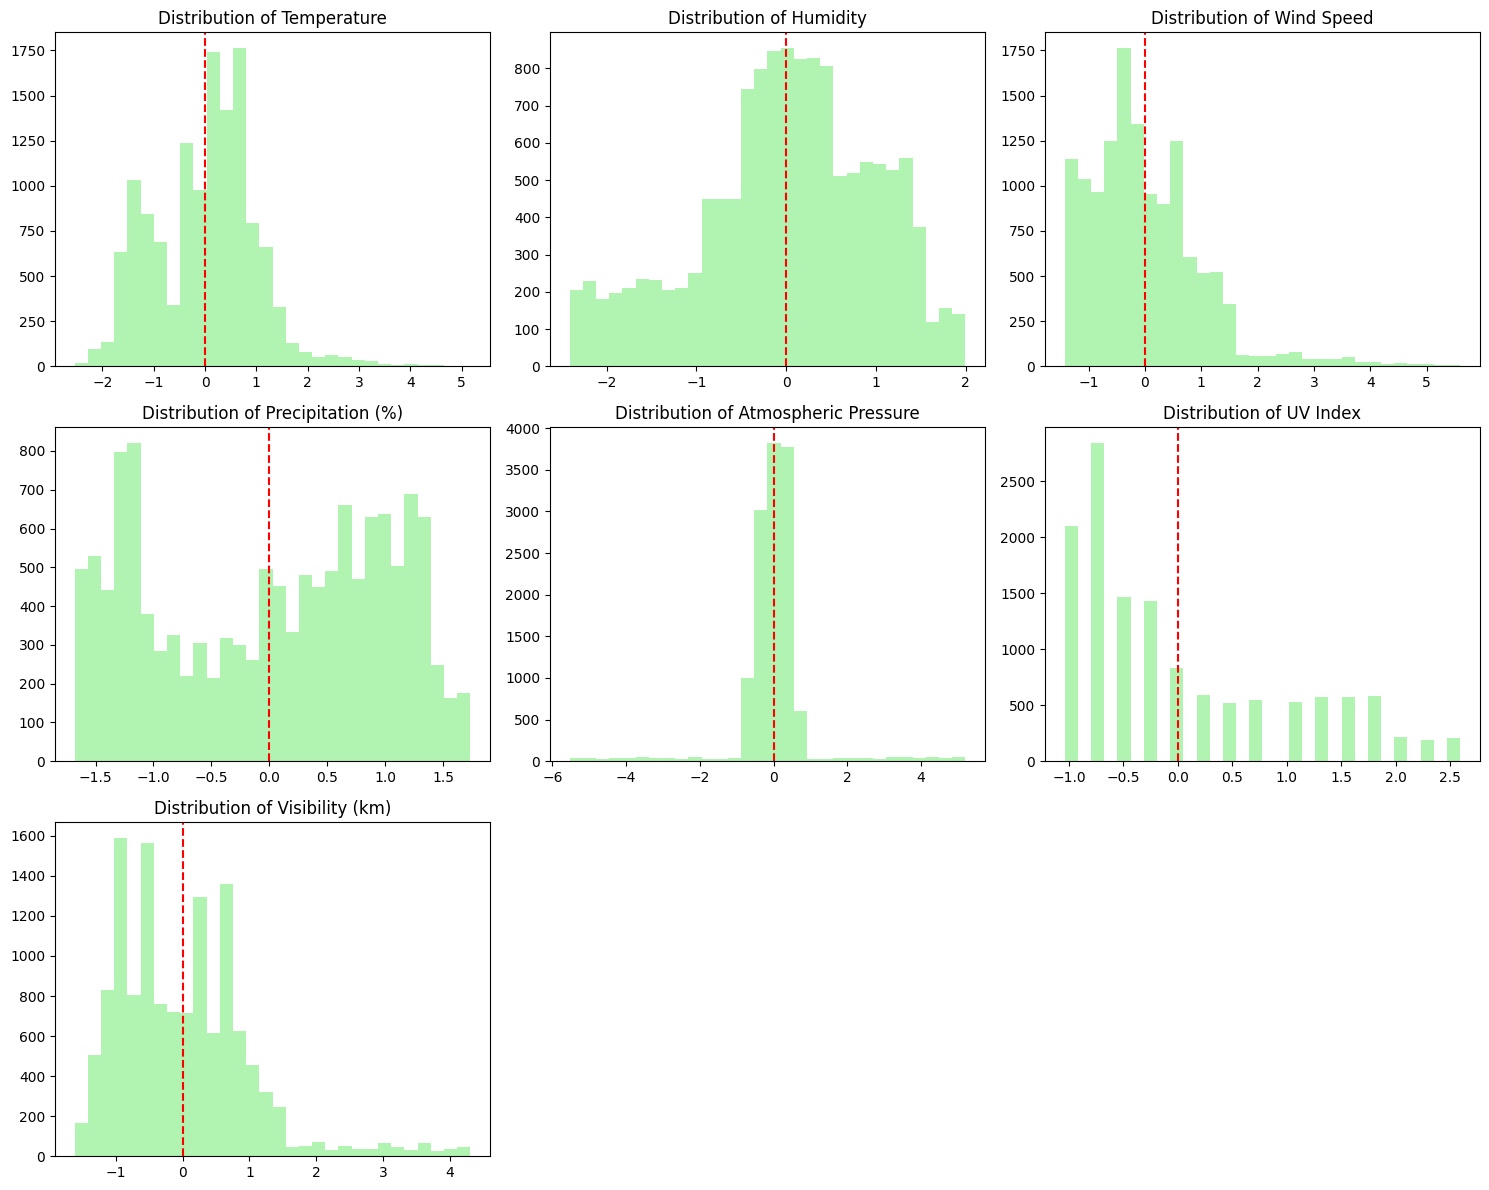

In [24]:
#Distribution of standardized features
standardized_cols = [col for col in numerical_features if col not in ['Weather_Type_encoded']]
n_cols = len(standardized_cols)

plt.figure(figsize=(15, 4*((n_cols+2)//3)))
for i, col in enumerate(standardized_cols):
    plt.subplot((n_cols+2)//3, 3, i+1)
    plt.hist(df_encoded[col], bins=30, alpha=0.7, color='lightgreen')
    plt.title(f'Distribution of {col}')
    plt.axvline(df_encoded[col].mean(), color='red', linestyle='--', label='Mean')

plt.tight_layout()
plt.show()

#Observations aftering running this code:
# Mean is 0 means these columns are stadardized correctly.
# See the graphs are observe weather graphs are normal or skewed distribution

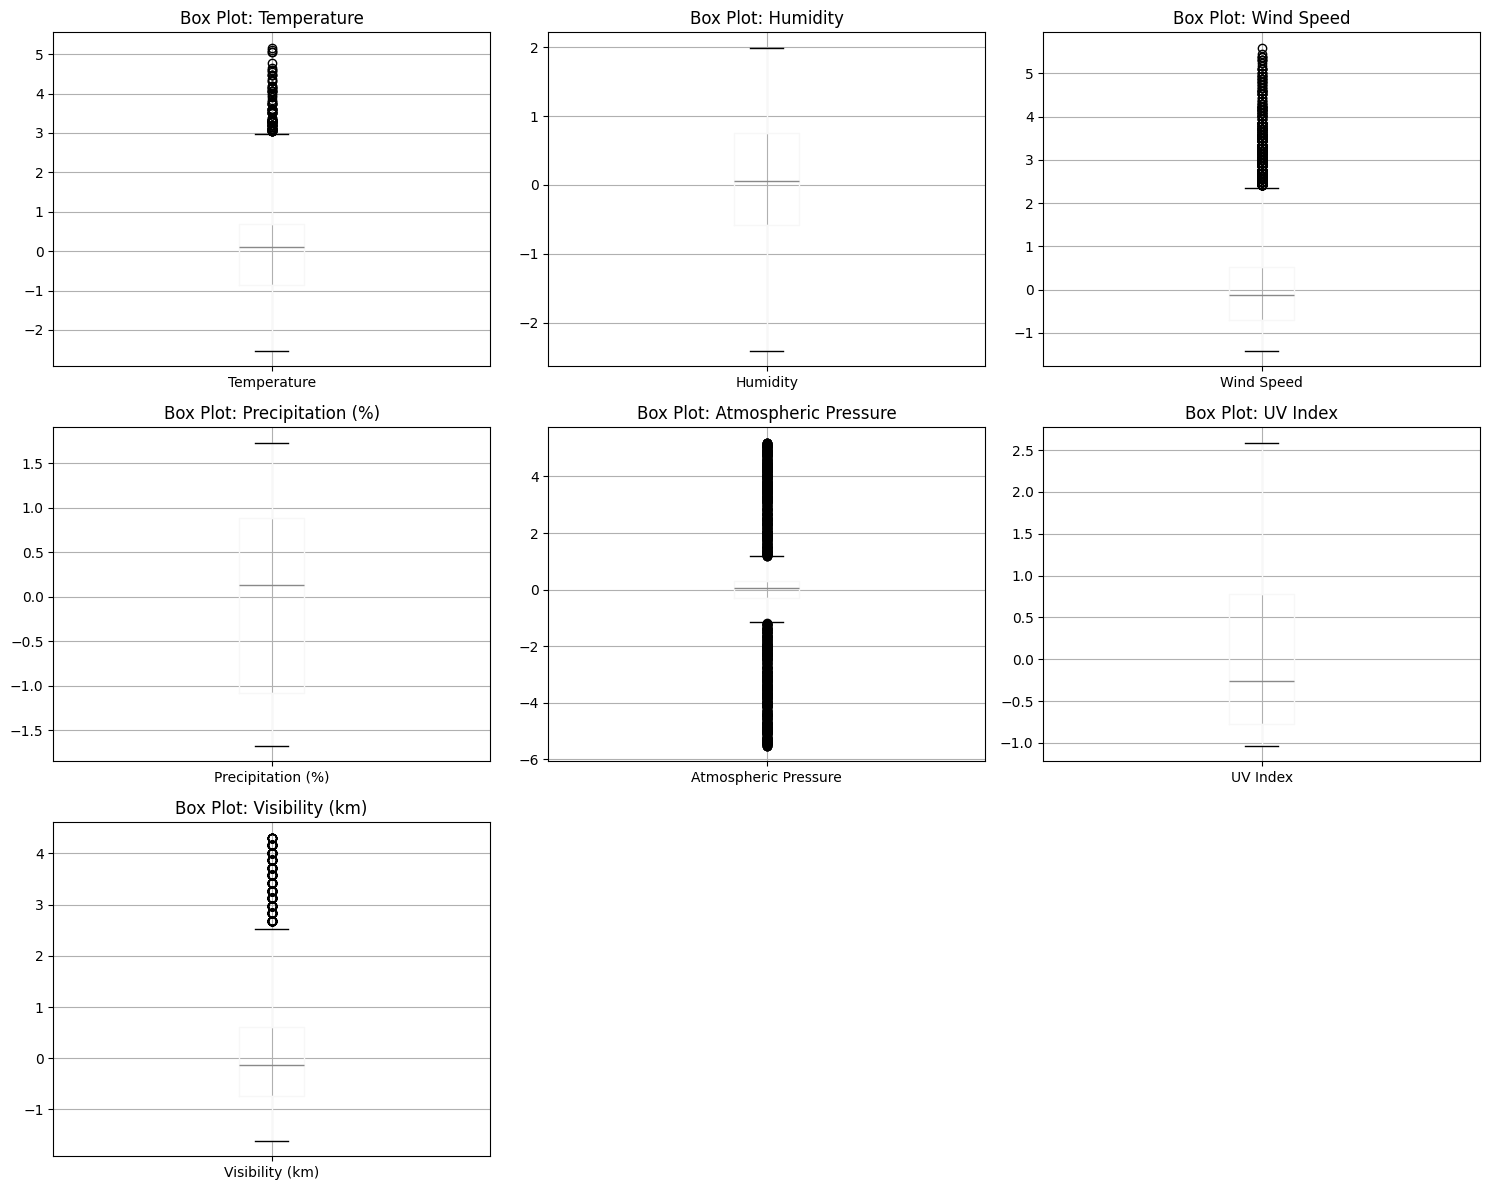

In [25]:
#creating Box plot for standardized numerical features
plt.figure(figsize=(15, 4*((n_cols+2)//3)))
for i, col in enumerate(standardized_cols):
    plt.subplot((n_cols+2)//3, 3, i+1)
    df_encoded.boxplot(column=col, ax=plt.gca())
    plt.title(f'Box Plot: {col}')

plt.tight_layout()
plt.show()

#observations:
# So median for all are close to 0 in rage from to -+0.5 which is correctly standardize some medians are slightly above or below 0 which are acceptable
# Atmospheric Pressure has widest range from 5 to -6 which means it has many outliers but median is centered means standardized correctly

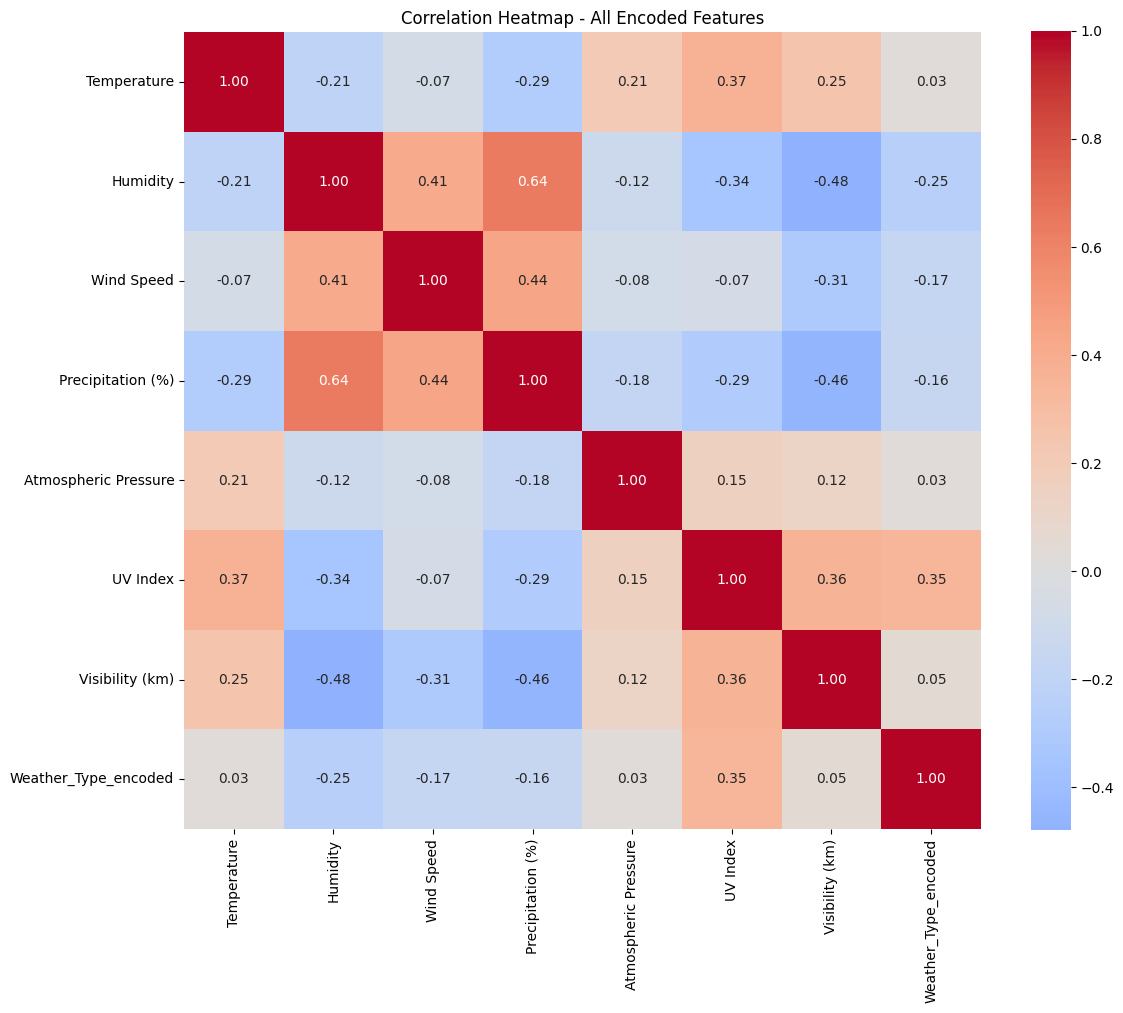

Strong correlations with target (|r| > 0.5):


In [27]:
#Corelation Heatmap for all featues:
correlation_matrix = df_encoded[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Heatmap - All Encoded Features')
plt.tight_layout()
plt.show()

print("Strong correlations with target (|r| > 0.5):")
target_corr = correlation_matrix['Weather_Type_encoded'].abs().sort_values(ascending=False)
for feature, corr_val in target_corr.items():
    if feature != 'Weather_Type_encoded' and corr_val > 0.5:
        print(f"{feature}: {corr_val:.3f}")
#observation:
# Multicollinearity Check: No corelation are greather then 0.7 so good for Ml. Highest corelation is btw humidity and perception which is 0.64 acceptable
# Target var (Weather Type) colrelation is 0.35 highest with UV index means no feature strongly predicts weather type.

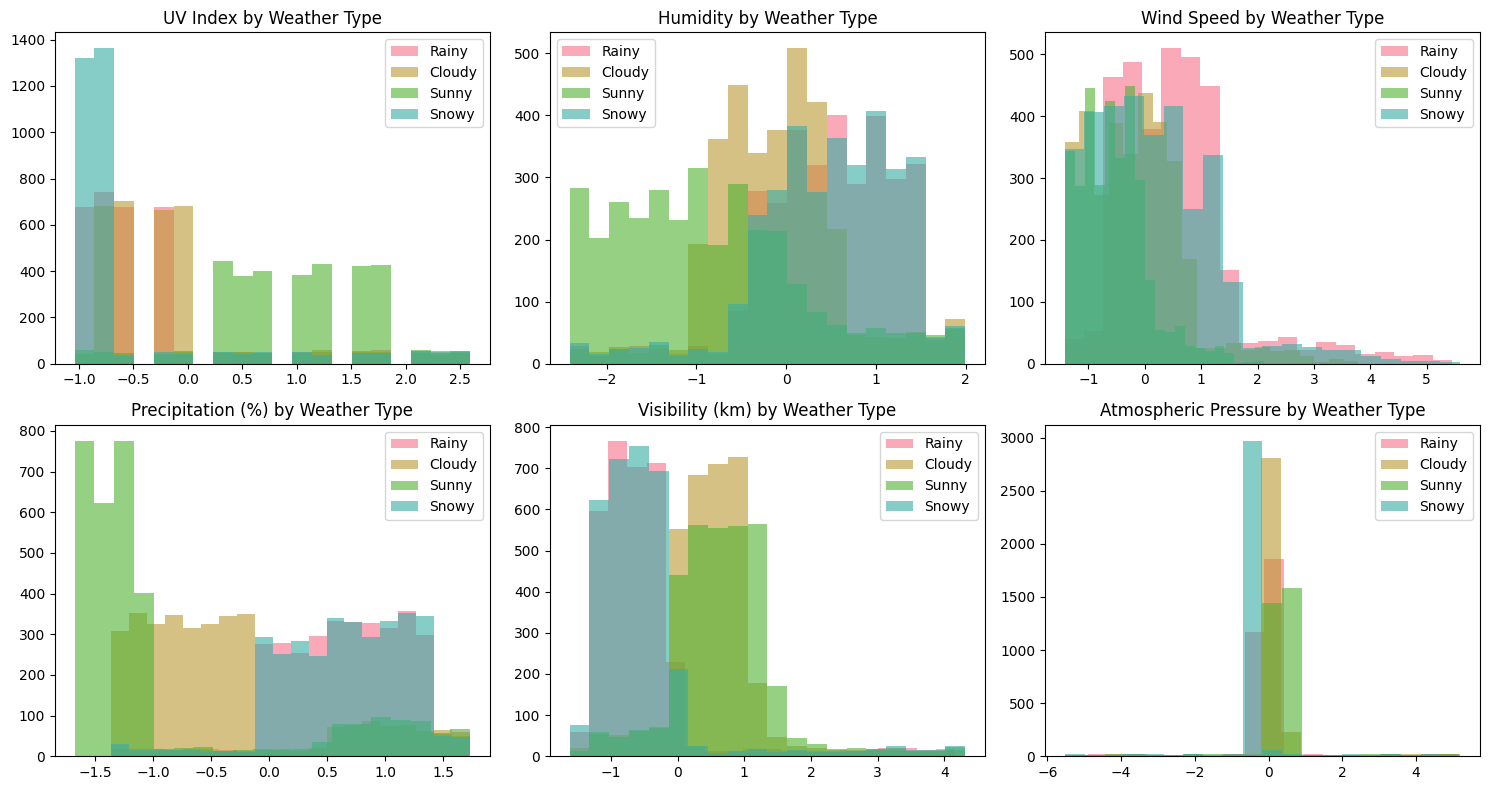

In [45]:
#Features vs Target analysis:

plt.figure(figsize=(15, 8))
important_features = correlation_matrix['Weather_Type_encoded'].abs().sort_values(ascending=False)[1:7]

for i, feature in enumerate(important_features.index):
    plt.subplot(2, 3, i+1)
    for weather_type in df_encoded['Weather Type'].unique():
        subset = df_encoded[df_encoded['Weather Type'] == weather_type]
        plt.hist(subset[feature], alpha=0.6, label=weather_type, bins=20)
    plt.title(f'{feature} by Weather Type')
    plt.legend()

plt.tight_layout()
plt.show()
#obervations:
#UV Index and Precipitation are the best weather predictors as they have clear seprations 
#Visibility also shows good separation after UV index and percipitation
#Wind Speed is the least useful for classification as all 4 types shows overlapping and no clear sepration patterns
#Multiple features will be needed for accurate classification as no single feature perfectly seprates all 4 weather types
#Weather types have distinct patterns making classification feasible as each weather type shows different distribution shapes and peak locations across features which
# indicate they have unique "signatures" that can be learned


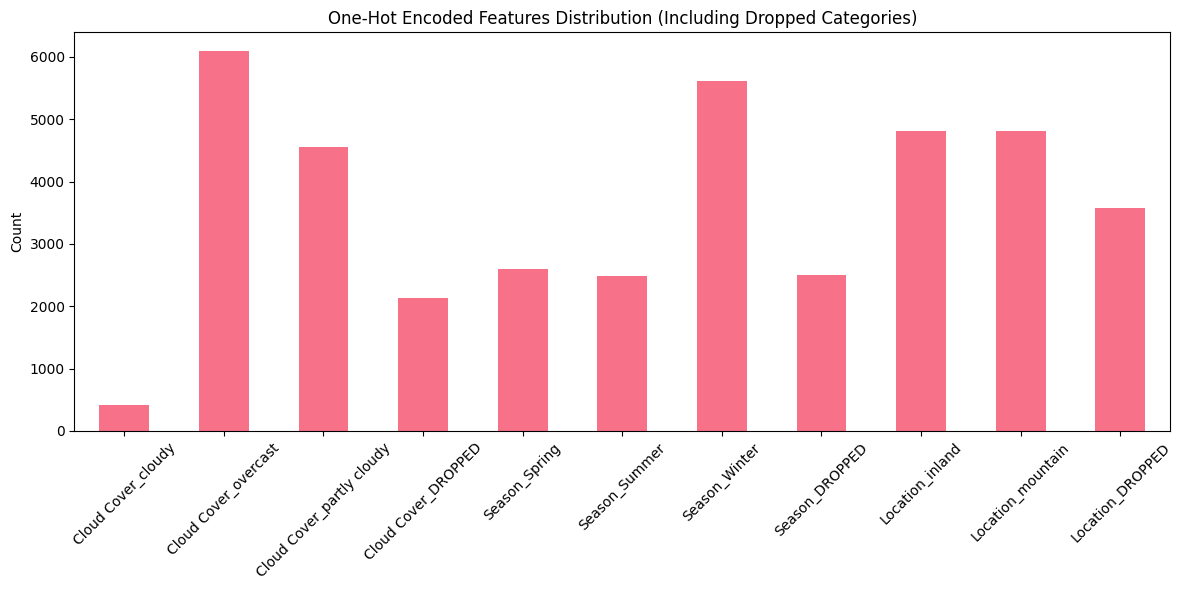

In [46]:
#One-Hot Encoded Features Analysis
columns_encoded = ["Cloud Cover", "Season", "Location"]
onehot_cols = [col for col in df_encoded.columns if col.startswith(tuple(columns_encoded))]

category_counts = {}

for feature in columns_encoded:
    # Get all one-hot columns for this feature
    feature_cols = [col for col in onehot_cols if col.startswith(feature)]
    
    # Sum counts for each category
    for col in feature_cols:
        category_counts[col] = df_encoded[col].sum()
    
    # Estimate dropped category count as drop_first=True so wee nedd to observe the dropped category also
    dropped_count = len(df_encoded) - df_encoded[feature_cols].sum(axis=1).sum()
    category_counts[f"{feature}_DROPPED"] = dropped_count

# Plot
plt.figure(figsize=(12, 6))
pd.Series(category_counts).plot(kind='bar')
plt.title('One-Hot Encoded Features Distribution (Including Dropped Categories)')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#observation:
#From cloud over: overcast occurs the most and cloudy occurs the least also drpped category is clear remmeber
#From season summer, autumn(dropped) and springs occurs equal time and winter occurs the most
#From Location costal(dropped) occurs less then inland and mountain

In [47]:
df_encoded.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Weather_Type_encoded,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,Rainy,1,False,False,True,False,False,True,True,False
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,Cloudy,0,False,False,True,True,False,False,True,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,Sunny,3,False,False,False,True,False,False,False,True
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,Sunny,3,False,False,False,True,False,False,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,Rainy,1,False,True,False,False,False,True,False,True


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare features and target
X = df_encoded.drop(['Weather Type', 'Weather_Type_encoded'], axis=1)  # All features except target
y = df_encoded['Weather_Type_encoded']  # Use encoded target (0,1,2,3)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in train set:")
print(pd.Series(y_train).value_counts().sort_index())

Training set: (10560, 15)
Test set: (2640, 15)
Class distribution in train set:
Weather_Type_encoded
0    2640
1    2640
2    2640
3    2640
Name: count, dtype: int64


In [52]:
# Model 1: Logistic Regression
# Reason: Good baseline for multi-class classification, works well with standardized features
# From EDA: Features are standardized and show linear separability patterns
lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr')
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("LOGISTIC REGRESSION RESULTS: ")
print(f"Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Rainy', 'Sunny', 'Cloudy', 'Snowy']))

LOGISTIC REGRESSION RESULTS: 
Accuracy: 0.8489

Classification Report:
              precision    recall  f1-score   support

       Rainy       0.80      0.82      0.81       660
       Sunny       0.83      0.83      0.83       660
      Cloudy       0.85      0.92      0.88       660
       Snowy       0.93      0.83      0.88       660

    accuracy                           0.85      2640
   macro avg       0.85      0.85      0.85      2640
weighted avg       0.85      0.85      0.85      2640



In [53]:
# Model 2: Decision Tree
# Reason: Can capture non-linear patterns and feature interactions
# From EDA: Multiple features needed together, tree can find complex decision boundaries
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("=== DECISION TREE RESULTS ===")
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Rainy', 'Sunny', 'Cloudy', 'Snowy']))

# Feature importance
print("\nTop 5 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head())

=== DECISION TREE RESULTS ===
Accuracy: 0.9087

Classification Report:
              precision    recall  f1-score   support

       Rainy       0.89      0.91      0.90       660
       Sunny       0.91      0.90      0.90       660
      Cloudy       0.93      0.91      0.92       660
       Snowy       0.91      0.91      0.91       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640


Top 5 Most Important Features:
                feature  importance
0           Temperature    0.299273
6       Visibility (km)    0.252307
5              UV Index    0.251285
3     Precipitation (%)    0.073882
4  Atmospheric Pressure    0.041056


In [54]:
# Model 3: Random Forest
# Reason: Handles outliers well, reduces overfitting, ensemble method for better performance
# From EDA: Atmospheric Pressure has many outliers, RF can handle this robustly
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, min_samples_split=10)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Rainy', 'Sunny', 'Cloudy', 'Snowy']))

# Feature importance
print("\nTop 5 Most Important Features:")
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(rf_feature_importance.head())

=== RANDOM FOREST RESULTS ===
Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

       Rainy       0.87      0.91      0.89       660
       Sunny       0.89      0.91      0.90       660
      Cloudy       0.96      0.91      0.93       660
       Snowy       0.93      0.92      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640


Top 5 Most Important Features:
                feature  importance
0           Temperature    0.189340
3     Precipitation (%)    0.152023
5              UV Index    0.151303
4  Atmospheric Pressure    0.140983
6       Visibility (km)    0.137902


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compare performance of all models
results = []
models_data = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred)
]

for model_name, pred in models_data:
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall': recall_score(y_test, pred, average='weighted'),
        'F1-Score': f1_score(y_test, pred, average='weighted')
    })

# Create comparison table
performance_df = pd.DataFrame(results).round(4)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(performance_df)

=== MODEL PERFORMANCE COMPARISON ===
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8489     0.8511  0.8489    0.8490
1        Decision Tree    0.9087     0.9089  0.9087    0.9088
2        Random Forest    0.9125     0.9137  0.9125    0.9128


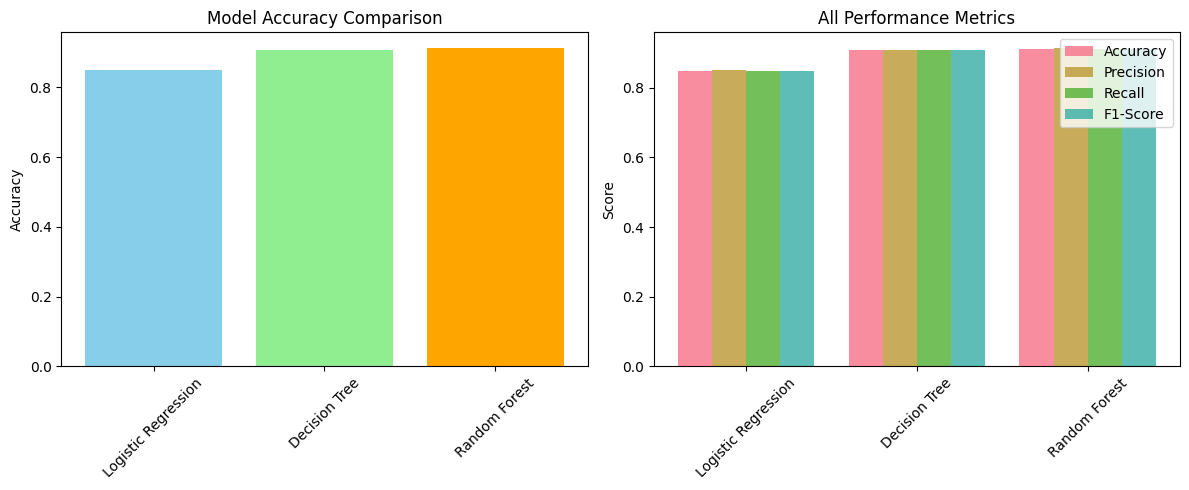

In [57]:
# Visualize model performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1.bar(performance_df['Model'], performance_df['Accuracy'], color=['skyblue', 'lightgreen', 'orange'])
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=45)

# All metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = range(len(performance_df))
width = 0.2
for i, metric in enumerate(metrics):
    ax2.bar([p + width*i for p in x], performance_df[metric], width, label=metric, alpha=0.8)
ax2.set_title('All Performance Metrics')
ax2.set_ylabel('Score')
ax2.set_xticks([p + width*1.5 for p in x])
ax2.set_xticklabels(performance_df['Model'], rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

In [59]:
# Identify and discuss best performing model
best_idx = performance_df['Accuracy'].idxmax()
best_model = performance_df.iloc[best_idx]

print("BEST MODEL ANALYSIS: ")
print(f"🏆 Best Model: {best_model['Model']}")
print(f"📊 Accuracy: {best_model['Accuracy']:.4f}")
print(f"📈 F1-Score: {best_model['F1-Score']:.4f}")

print(f"\n Why {best_model['Model']} performed best:")
if best_model['Model'] == 'Random Forest':
    print("• Handles outliers well (Atmospheric Pressure had many outliers from EDA)")
    print("• Ensemble method reduces overfitting")
    print("• Captures complex feature interactions")
elif best_model['Model'] == 'Decision Tree':
    print("• Captures non-linear patterns and feature interactions")
    print("• Good at finding decision boundaries for weather classification")
elif best_model['Model'] == 'Logistic Regression':
    print("• Works well with standardized features")
    print("• Benefits from linear separability shown in EDA")

print(f"\n Conclusion: {best_model['Model']} is recommended for weather classification")

BEST MODEL ANALYSIS: 
🏆 Best Model: Random Forest
📊 Accuracy: 0.9125
📈 F1-Score: 0.9128

 Why Random Forest performed best:
• Handles outliers well (Atmospheric Pressure had many outliers from EDA)
• Ensemble method reduces overfitting
• Captures complex feature interactions

 Conclusion: Random Forest is recommended for weather classification
